# Demo 04 - Naive Bayes

**Simplified Notes: Naive Bayes Classifier Overview**
1. **Concept of Naive Bayes**:
   - **Origin**: Based on Bayes' Theorem, developed by Reverend Thomas Bayes.
   - **Application**: Widely used in early email spam detection.

2. **Bayes’ Theorem Basics**:
   - **Formula**: Probability of a class given evidence = (Likelihood * Prior Probability) / Evidence Probability.
   - **Interpretation**:
     - We’re predicting the likelihood of a class (e.g., “ill” or “healthy”) based on observed data (features like blood pressure, height).
     - By using **Bayesian statistics**, we infer probabilities based on prior data.

3. **Understanding “Naive” Assumption**:
   - **Independence Assumption**: Assumes features are independent of each other, which isn’t always realistic but simplifies calculations.
   - **Example**: Predicting whether a person is healthy based on independent features like height and blood pressure.

4. **Implementing Naive Bayes**:
   - **Training Data**: Use a training dataset to determine prior probabilities.
   - **Feature Independence**: Calculate individual probabilities for each feature given a class label.
   - **Gaussian (Normal) Distribution**: Commonly used for continuous features (e.g., height). For non-continuous, other distributions like Bernoulli or Poisson might apply.

5. **Gaussian Distribution Basics**:
   - **Parameters Needed**: Mean (μ) and variance (σ²) are required to calculate the Gaussian probability.
   - **Formula**: 
     \[
     P(x|\text{class}) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)}
     \]

6. **Working with a Classification Example**:
   - **Class 0 vs Class 1**: Generate synthetic data to train the Naive Bayes model.
   - **Prior Probabilities**: Calculate the ratio of each class in the training data (e.g., 40% for Class 0 and 60% for Class 1).

7. **Predicting with Naive Bayes**:
   - **Likelihood Calculation**: For a new data point, calculate the likelihood of each class based on feature probabilities.
   - **Prediction**: Compare the likelihoods to assign the class with the higher likelihood as the predicted label.

8. **Practical Coding Notes**:
    - **Data Generation**: Use `scikit-learn` for sample data.
    - **Implementation**: The Naive Bayes classifier can be programmed by computing individual probabilities and then combining them.
    - **Optimization**: While this method works for small-scale problems, more efficient implementations are needed for larger datasets.

In [1]:

from matplotlib import pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap
from sklearn.naive_bayes import GaussianNB
    

### Generate some toy-data

In [2]:

X, y = make_blobs(n_samples=[10, 15, 20], n_features=2, centers=[[-1, -1], [0, 1], [1, 0]])
X, y
    

(array([[ 0.54225013, -2.25662328],
        [ 1.1206119 ,  0.49231415],
        [-1.70946923,  0.31168693],
        [ 0.08893308, -1.47415978],
        [ 0.22756185,  0.79639342],
        [ 2.41061154, -1.42764764],
        [ 1.95256522,  0.9674298 ],
        [-1.79769542, -0.11732459],
        [ 1.02040378,  1.95523454],
        [ 0.53990895,  1.25933717],
        [-0.13593327,  0.42474869],
        [-2.47345237,  1.16813383],
        [ 1.84743624,  0.24054487],
        [ 2.01491399, -0.68002256],
        [ 1.34541656, -1.07002155],
        [ 0.52770883, -1.94471814],
        [ 1.86773642, -2.11236038],
        [-0.34787577, -2.91674607],
        [-0.55058003, -2.36826868],
        [ 1.03521215,  2.24799058],
        [ 0.29957506, -0.27555858],
        [-1.48015738,  0.19470392],
        [ 1.20114879, -1.01943792],
        [-0.75649836,  2.73712047],
        [-0.36226785, -2.16415234],
        [-0.12202124, -1.82949047],
        [ 3.44065199,  1.21791376],
        [-2.01146618, -0.744

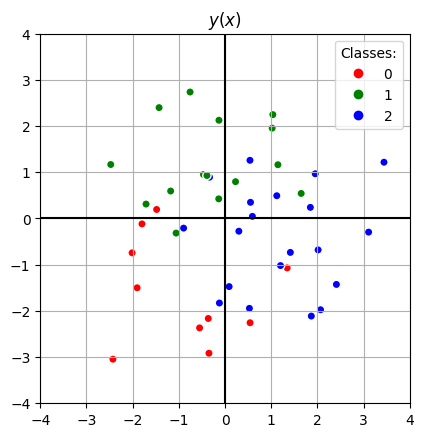

In [3]:

# Visualize the data
rgb_map = ListedColormap(('r', 'g', 'b'))
plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$y(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()
    

### Naive Bayes Formula

In [4]:

# Naive Bayes calculations
classes = np.unique(y)
var = np.array([np.var(X[y == c, :], axis=0) for c in classes])
theta = np.array([np.mean(X[y == c, :], axis=0) for c in classes])
classes, theta, var
    

(array([0, 1, 2]),
 array([[-0.89912315, -1.59888115],
        [-0.31019984,  1.20215884],
        [ 1.18455831, -0.42550943]]),
 array([[1.35506719, 1.16065181],
        [1.28752489, 0.74110545],
        [1.26228902, 1.17813744]]))

In [5]:

# Prediction function based on Gaussian Naive Bayes
def predict_proba(X):
    '''Compute Gaussian Naive Bayes probabilities via likelihoods.'''
    Pyx = list()
    for c in range(len(classes)):
        Pxy = np.exp(-0.5 * (X - theta[c]) ** 2 / var[c]) / np.sqrt(2.0 * np.pi * var[c])
        Py = np.mean(y == classes[c])
        Pyx.append(Pxy.prod(axis=1) * Py)
    Pyx = np.array(Pyx).T
    return Pyx / Pyx.sum(axis=1, keepdims=True)

y_proba = predict_proba(X)
y_proba
    

array([[4.77826323e-01, 5.62237183e-04, 5.21611440e-01],
       [1.61511069e-02, 2.96323624e-01, 6.87525269e-01],
       [2.17347915e-01, 7.03667442e-01, 7.89846437e-02],
       [4.59164282e-01, 9.55785818e-03, 5.31277860e-01],
       [2.24724628e-02, 6.54736282e-01, 3.22791255e-01],
       [2.28543868e-02, 1.34762930e-03, 9.75797984e-01],
       [3.00033910e-03, 2.61475718e-01, 7.35523942e-01],
       [4.81724205e-01, 4.20876420e-01, 9.73993752e-02],
       [1.31624898e-03, 7.81445959e-01, 2.17237792e-01],
       [6.93902405e-03, 7.30006863e-01, 2.63054113e-01],
       [6.39038581e-02, 5.85352155e-01, 3.50743986e-01],
       [4.47368414e-02, 9.44707957e-01, 1.05552014e-02],
       [8.91030480e-03, 1.04777508e-01, 8.86312187e-01],
       [1.92345154e-02, 1.37290361e-02, 9.67036449e-01],
       [7.40628053e-02, 1.09354992e-02, 9.15001696e-01],
       [4.07027692e-01, 1.67055450e-03, 5.91301754e-01],
       [9.38624085e-02, 3.26776760e-04, 9.05810815e-01],
       [8.78929102e-01, 4.27578

In [6]:

# Predicted class
y_hat = classes[np.argmax(y_proba, axis=1)]
y_hat
    

array([2, 2, 1, 2, 1, 2, 2, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 1, 2, 1,
       2, 1, 0, 0, 2, 0, 1, 1, 0, 1, 0, 2, 1, 0, 2, 2, 2, 1, 1, 2, 2, 1,
       1])

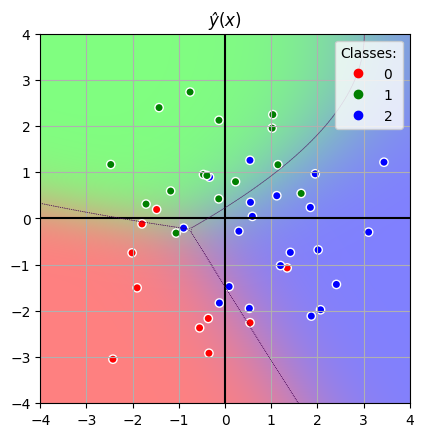

In [7]:

# Mesh grid for decision boundary
xx1, xx2 = np.meshgrid(np.linspace(-4.0, 4.0, 81), np.linspace(-4.0, 4.0, 81))
XX = np.array([xx1.ravel(), xx2.ravel()]).T
yy = predict_proba(XX).reshape(xx1.shape + (3, ))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.imshow(yy, extent=(-4.0, 4.0, -4.0, 4.0), origin='lower', interpolation='bilinear', alpha=0.5)
for z in range(yy.shape[2]):
    plt.contour(xx1, xx2, yy[:, :, z] / (1.0 - yy.min(axis=2)), [0.5], linewidths=0.5, linestyles='dotted')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$ŷ(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()
    

### Log-likelihood Naive Bayes Formula

In [8]:

# Prediction function based on log-likelihoods
def predict_proba(X):
    '''Compute Gaussian Naive Bayes probabilities via log-likelihoods.'''
    log_Pyx = list()
    for c in range(len(classes)):
        log_Pxy = -0.5 * (np.log(var[c]) + (X - theta[c]) ** 2 / var[c])
        log_Py = np.log(np.mean(y == classes[c]))
        log_Pyx.append(log_Pxy.sum(axis=1) + log_Py)
    log_Pyx = np.array(log_Pyx).T
    log_Pyx -= log_Pyx.max(axis=1, keepdims=True)
    Pyx = np.exp(log_Pyx)
    return Pyx / Pyx.sum(axis=1, keepdims=True)

y_proba = predict_proba(X)
y_proba
    

array([[4.77826323e-01, 5.62237183e-04, 5.21611440e-01],
       [1.61511069e-02, 2.96323624e-01, 6.87525269e-01],
       [2.17347915e-01, 7.03667442e-01, 7.89846437e-02],
       [4.59164282e-01, 9.55785818e-03, 5.31277860e-01],
       [2.24724628e-02, 6.54736282e-01, 3.22791255e-01],
       [2.28543868e-02, 1.34762930e-03, 9.75797984e-01],
       [3.00033910e-03, 2.61475718e-01, 7.35523942e-01],
       [4.81724205e-01, 4.20876420e-01, 9.73993752e-02],
       [1.31624898e-03, 7.81445959e-01, 2.17237792e-01],
       [6.93902405e-03, 7.30006863e-01, 2.63054113e-01],
       [6.39038581e-02, 5.85352155e-01, 3.50743986e-01],
       [4.47368414e-02, 9.44707957e-01, 1.05552014e-02],
       [8.91030480e-03, 1.04777508e-01, 8.86312187e-01],
       [1.92345154e-02, 1.37290361e-02, 9.67036449e-01],
       [7.40628053e-02, 1.09354992e-02, 9.15001696e-01],
       [4.07027692e-01, 1.67055450e-03, 5.91301754e-01],
       [9.38624085e-02, 3.26776760e-04, 9.05810815e-01],
       [8.78929102e-01, 4.27578

### Using Scikit-learn

In [9]:

# Using Gaussian Naive Bayes from sklearn
model = GaussianNB()
model.fit(X, y)
model.classes_, model.theta_, model.var_
    

(array([0, 1, 2]),
 array([[-0.89912315, -1.59888115],
        [-0.31019984,  1.20215884],
        [ 1.18455831, -0.42550943]]),
 array([[1.35506719, 1.16065181],
        [1.28752489, 0.74110545],
        [1.26228902, 1.17813744]]))

In [10]:

# Predicted probabilities using sklearn model
y_hat = model.predict_proba(X)
y_hat
    

array([[4.77826323e-01, 5.62237194e-04, 5.21611440e-01],
       [1.61511069e-02, 2.96323624e-01, 6.87525269e-01],
       [2.17347915e-01, 7.03667441e-01, 7.89846440e-02],
       [4.59164282e-01, 9.55785830e-03, 5.31277860e-01],
       [2.24724629e-02, 6.54736282e-01, 3.22791256e-01],
       [2.28543869e-02, 1.34762933e-03, 9.75797984e-01],
       [3.00033912e-03, 2.61475719e-01, 7.35523942e-01],
       [4.81724204e-01, 4.20876420e-01, 9.73993754e-02],
       [1.31624900e-03, 7.81445958e-01, 2.17237793e-01],
       [6.93902410e-03, 7.30006862e-01, 2.63054114e-01],
       [6.39038582e-02, 5.85352155e-01, 3.50743987e-01],
       [4.47368416e-02, 9.44707957e-01, 1.05552015e-02],
       [8.91030485e-03, 1.04777508e-01, 8.86312187e-01],
       [1.92345155e-02, 1.37290362e-02, 9.67036448e-01],
       [7.40628054e-02, 1.09354993e-02, 9.15001695e-01],
       [4.07027692e-01, 1.67055453e-03, 5.91301754e-01],
       [9.38624087e-02, 3.26776767e-04, 9.05810815e-01],
       [8.78929102e-01, 4.27578

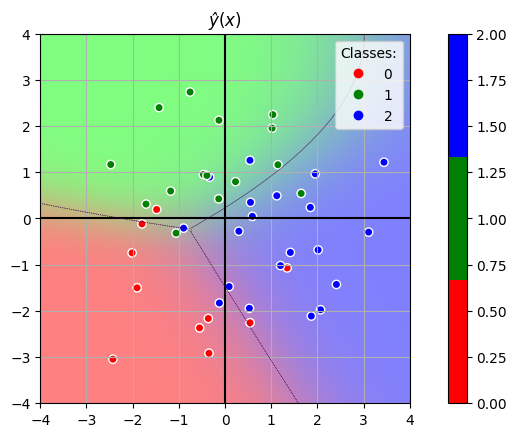

In [11]:

# Prediction visualization using sklearn
y_hat = model.predict(X)
yy = model.predict_proba(XX).reshape(xx1.shape + (3, ))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.imshow(yy, extent=(-4.0, 4.0, -4.0, 4.0), origin='lower', interpolation='bilinear', alpha=0.5)
for z in range(yy.shape[2]):
    plt.contour(xx1, xx2, yy[:, :, z] / (1.0 - yy.min(axis=2)), [0.5], linewidths=0.5, linestyles='dotted')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.colorbar()
plt.title('$ŷ(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()
    

© 2024 - Dave R.M. Langers d.r.m.langers@pl.hanze.nl


**Dave Langers on Multi-Class Classification and Soft Voting Implementation:**

- Langers described using multiple classifiers trained on pairs of classes to perform multi-class classification. By applying all classifiers and letting them vote, the system can distinguish the most likely class. This approach, called "One-vs-Rest" or "One-vs-All," involves training one classifier per class against the rest of the classes.
  
- Langers explained two voting methods:
  - **Hard Voting:** Counts votes from each classifier, selecting the class with the most votes.
  - **Soft Voting:** Averages the probability estimates for each class and selects the class with the highest probability.

- He demonstrated implementing a soft voting class in Python:
  - First, he created base learners like `LogisticRegression` and `DecisionTreeClassifier` from `sklearn`.
  - In the voting class, each classifier fits the training data, and during prediction, probabilities are averaged for each class.

- **Soft Voting Class Structure:**
  - **Initialization:** Receives base learners as input.
  - **Fitting:** Trains each base learner on the full dataset.
  - **Predicting:** Computes the average probability for each class across learners and returns the class with the highest probability.

- **Additional Notes on Method Chaining and Prediction Boundaries:**
  - Langers emphasized method chaining for cleaner code and demonstrated how to visualize decision boundaries in multi-class classification.
